# LDSC for male/female GWAS

## Getting Started

In [3]:
## Import the necessary packages 
import os
import numpy as np
import pandas as pd
import math
import numbers
import sys
import subprocess
import statsmodels.api as sm
import scipy
from scipy import stats
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

## Print out package versions
## Getting packages loaded into this notebook and their versions to allow for reproducibility
    # Repurposed code from stackoverflow here: https://stackoverflow.com/questions/40428931/package-for-listing-version-of-packages-used-in-a-jupyter-notebook

## Import packages 
import pkg_resources
import types
from datetime import date
today = date.today()
date = today.strftime("%d-%b-%Y").upper()

## Define function 
def get_imports():
    for name, val in globals().items():
        if isinstance(val, types.ModuleType):
            # Split ensures you get root package, not just imported function
            name = val.__name__.split(".")[0]

        elif isinstance(val, type):
            name = val.__module__.split(".")[0]

        # Some packages are weird and have different imported names vs. system/pip names
        # Unfortunately, there is no systematic way to get pip names from a package's imported name. You'll have to add exceptions to this list manually!
        poorly_named_packages = {
            "PIL": "Pillow",
            "sklearn": "scikit-learn"
        }
        if name in poorly_named_packages.keys():
            name = poorly_named_packages[name]

        yield name

## Get a list of packages imported 
imports = list(set(get_imports()))

# The only way I found to get the version of the root package from only the name of the package is to cross-check the names of installed packages vs. imported packages
requirements = []
for m in pkg_resources.working_set:
    if m.project_name in imports and m.project_name!="pip":
        requirements.append((m.project_name, m.version))

## Print out packages and versions 
print(f"PACKAGE VERSIONS ({date})")
for r in requirements:
    print("\t{}=={}".format(*r))

PACKAGE VERSIONS (10-JUL-2025)
	matplotlib==3.10.3
	seaborn==0.13.2
	statsmodels==0.14.4
	numpy==1.24.4
	pandas==2.0.3
	scipy==1.11.1


# Pre-processing LDSC

In [ ]:
! head {WORK_DIR}/METAS/FINAL/ALL_FEMALE_COMBINED_FILTERED.meta

CHR	BP	SNP	A1	A2	N	P	P(R)	BETA	BETA(R)	Q	I	WEIGHTED_Z	P(WZ)	F0	F1	F2	F3	F4	F5	F6	F7	F8	F9	F10	F11	F12	F13	F14
1	727233	chr1:727233:G:A	A	G	9	0.6272	0.6272	0.0351	0.0351	0.8162	0.0	0.4599	0.6456	-0.0344		0.8341			-0.4963	-0.4832		0.1054		-0.0368		0.0224	0.1105	0.4524
1	758443	chr1:758443:G:C	C	G	9	0.6601	0.8621	-0.0152	-0.0081	0.2467	22.09	-0.307	0.7588	0.0321	0.4318	-0.1239			-0.1065			0.6097		0.1601		-0.0784	-0.0728	-0.0634
1	766399	chr1:766399:GAATA:G	G	GAATA	9	0.7214	0.7214	0.0169	0.0169	0.5559	0.0	0.3488	0.7272	0.0447	-0.3215	-0.543			-0.014	-0.1838		-0.4303				-0.0038	0.1104	-0.3693
1	769257	chr1:769257:G:A	A	G	10	0.8416	0.8078	0.0101	0.0169	0.2415	21.9	0.1979	0.8431	0.0015	0.4925	0.6442			-0.219	-0.8762		-0.0791		-0.4416		-0.1027	0.0924	0.0478
1	771516	chr1:771516:G:A	A	G	9	0.83	0.83	0.0102	0.0102	0.4862	0.0	0.2023	0.8397	0.0265	-0.2447	-0.5732			-0.0084	-0.1861		-0.5584				-0.0103	0.12	-0.3501
1	772506	chr1:772506:G:C	C	G	9	0.7643	0.7643	0.0141	0.0141	0.4734	0.0	0.2801	0.7794	0.

In [ ]:
! head {WORK_DIR}/METAS/FINAL/ALL_MALE_COMBINED_FILTERED.meta

CHR	BP	SNP	A1	A2	N	P	P(R)	BETA	BETA(R)	Q	I	WEIGHTED_Z	P(WZ)	F0	F1	F2	F3	F4	F5	F6	F7	F8	F9	F10	F11	F12	F13	F14
1	727233	chr1:727233:G:A	A	G	9	0.0133	0.0133	-0.1602	-0.1602	0.8866	0.0	-2.354	0.01857	-0.1581		-0.1716			0.3159	0.3802		0.0746		0.4162		-0.2722	-0.159	0.3736
1	758443	chr1:758443:G:C	C	G	9	0.3381	0.3381	0.0279	0.0279	0.4953	0.0	0.8861	0.3755	0.0452	0.2213	-0.3177			0.3583			-0.1596		0.136		0.0479	-0.0496	-0.061
1	766399	chr1:766399:GAATA:G	G	GAATA	9	0.6468	0.6331	0.0187	0.0205	0.4092	3.06	0.497	0.6192	-0.0119	-0.1071	1.3991			-0.0379	0.1187		0.204				0.0152	0.0118	0.3321
1	769257	chr1:769257:G:A	A	G	10	0.3535	0.3535	-0.0402	-0.0402	0.9879	0.0	-0.9596	0.3372	-0.0242	-0.0317	0.0088			0.1584	0.1241		-0.138		-0.5951		-0.0232	-0.0875	-0.15
1	771516	chr1:771516:G:A	A	G	9	0.6035	0.5589	0.0212	0.0277	0.3544	9.69	0.5467	0.5846	-0.0219	-0.1763	1.3943			0.0067	0.125		0.1887				0.0182	0.0356	0.3897
1	772506	chr1:772506:G:C	C	G	9	0.5387	0.518	0.0249	0.0293	0.376	7.12	0.6389	0.5229	-0.0153	

## Annotation

In [5]:
def convert_file_forANNOVAR(input_file, output_file):
    df = pd.read_csv(input_file, delim_whitespace=True)
    
    # Split the SNP column to get the REF and ALT values
    snp_split = df['SNP'].str.split(':', expand=True)
    df['REF'] = snp_split[2]  # Reference allele
    df['ALT'] = snp_split[3]  # Alternative allele

    output_df = pd.DataFrame({
        'Chr': df['CHR'],
        'Start': df['BP'],
        'End': df['BP'],
        'Ref': df['REF'],
        'Alt': df['ALT'],
        'ID': df['SNP'],
    })

    # Write to the output file
    output_df.to_csv(output_file, sep='\t', index=False)

## Combined

### Female 

In [ ]:
## Female
convert_file_forANNOVAR(f"{WORK_DIR}/METAS/FINAL/ALL_FEMALE_COMBINED_FILTERED.meta", \
                        f"{LDSC_DIR}/preprocessing/step1_preANNOVAR/ALL_FEMALE_COMBINED_FILTERED.meta.forANNOVAR.meta")

In [12]:
sh_script = f"""#!/bin/bash

ml annovar

table_annovar.pl {LDSC_DIR}/preprocessing/step1_preANNOVAR/ALL_FEMALE_COMBINED_FILTERED.meta.forANNOVAR.meta $ANNOVAR_DATA/hg38 \
-buildver hg38 \\
-out {LDSC_DIR}/preprocessing/step2_postANNOVAR/ALL_FEMALE_COMBINED_FILTERED.ANNOVAR.meta \\
-remove \\
-protocol avsnp150 \\
-operation f \\
-nastring . \\
-polish
"""

script_file = f'{LDSC_DIR}/scripts/ANNOVAR.ALL_FEMALE_COMBINED_FILTERED.sh'
with open(script_file, 'w') as file:
    file.write(sh_script)

In [13]:
%%bash

cd ${LDSC_DIR}/scripts 

sbatch --cpus-per-task=2 \
--mem=100g \
--time=12:00:00 \
--mail-type=BEGIN,FAIL,TIME_LIMIT_80,END ANNOVAR.ALL_FEMALE_COMBINED_FILTERED.sh

62072670


### Male

In [ ]:
## Male
convert_file_forANNOVAR(f"{WORK_DIR}/METAS/FINAL/ALL_MALE_COMBINED_FILTERED.meta", \
                        f"{LDSC_DIR}/preprocessing/step1_preANNOVAR/ALL_MALE_COMBINED_FILTERED.meta.forANNOVAR.meta")

In [14]:
sh_script = f"""#!/bin/bash

ml annovar

table_annovar.pl {LDSC_DIR}/preprocessing/step1_preANNOVAR/ALL_MALE_COMBINED_FILTERED.meta.forANNOVAR.meta $ANNOVAR_DATA/hg38 \
-buildver hg38 \\
-out {LDSC_DIR}/preprocessing/step2_postANNOVAR/ALL_MALE_COMBINED_FILTERED.ANNOVAR.meta \\
-remove \\
-protocol avsnp150 \\
-operation f \\
-nastring . \\
-polish
"""

script_file = f'{LDSC_DIR}/scripts/ANNOVAR.ALL_MALE_COMBINED_FILTERED.sh'
with open(script_file, 'w') as file:
    file.write(sh_script)

In [15]:
%%bash

cd ${LDSC_DIR}/scripts 

sbatch --cpus-per-task=2 \
--mem=100g \
--time=12:00:00 \
--mail-type=BEGIN,FAIL,TIME_LIMIT_80,END ANNOVAR.ALL_MALE_COMBINED_FILTERED.sh

62072719


## EUR only

### Female

In [ ]:
## Female
convert_file_forANNOVAR(f"{WORK_DIR}/METAS/FINAL/EUR_FEMALE_FILTERED.meta", \
                        f"{LDSC_DIR}/preprocessing/step1_preANNOVAR/EUR_FEMALE_FILTERED.meta.forANNOVAR.meta")

In [7]:
sh_script = f"""#!/bin/bash

ml annovar

table_annovar.pl {LDSC_DIR}/preprocessing/step1_preANNOVAR/EUR_FEMALE_FILTERED.meta.forANNOVAR.meta $ANNOVAR_DATA/hg38 \
-buildver hg38 \\
-out {LDSC_DIR}/preprocessing/step2_postANNOVAR/EUR_FEMALE_FILTERED.ANNOVAR.meta \\
-remove \\
-protocol avsnp150 \\
-operation f \\
-nastring . \\
-polish
"""

script_file = f'{LDSC_DIR}/scripts/ANNOVAR.EUR_FEMALE_FILTERED.sh'
with open(script_file, 'w') as file:
    file.write(sh_script)

In [8]:
%%bash

cd ${LDSC_DIR}/scripts 

sbatch --cpus-per-task=2 \
--mem=100g \
--time=12:00:00 \
--mail-type=BEGIN,FAIL,TIME_LIMIT_80,END ANNOVAR.EUR_FEMALE_FILTERED.sh

62197142


### Male

In [ ]:
## Male
convert_file_forANNOVAR(f"{WORK_DIR}/METAS/FINAL/EUR_MALE_FILTERED.meta", \
                        f"{LDSC_DIR}/preprocessing/step1_preANNOVAR/EUR_MALE_FILTERED.meta.forANNOVAR.meta")

In [10]:
sh_script = f"""#!/bin/bash

ml annovar

table_annovar.pl {LDSC_DIR}/preprocessing/step1_preANNOVAR/EUR_MALE_FILTERED.meta.forANNOVAR.meta $ANNOVAR_DATA/hg38 \
-buildver hg38 \\
-out {LDSC_DIR}/preprocessing/step2_postANNOVAR/EUR_MALE_FILTERED.ANNOVAR.meta \\
-remove \\
-protocol avsnp150 \\
-operation f \\
-nastring . \\
-polish
"""

script_file = f'{LDSC_DIR}/scripts/ANNOVAR.EUR_MALE_FILTERED.sh'
with open(script_file, 'w') as file:
    file.write(sh_script)

In [11]:
%%bash

cd ${LDSC_DIR}/scripts 

sbatch --cpus-per-task=2 \
--mem=100g \
--time=12:00:00 \
--mail-type=BEGIN,FAIL,TIME_LIMIT_80,END ANNOVAR.EUR_MALE_FILTERED.sh

62197283


## AJ only

### Female

In [ ]:
## Female
convert_file_forANNOVAR(f"{WORK_DIR}/METAS/FINAL/AJ_FEMALE_FILTERED.meta", \
                        f"{LDSC_DIR}/preprocessing/step1_preANNOVAR/AJ_FEMALE_FILTERED.meta.forANNOVAR.meta")

In [13]:
sh_script = f"""#!/bin/bash

ml annovar

table_annovar.pl {LDSC_DIR}/preprocessing/step1_preANNOVAR/AJ_FEMALE_FILTERED.meta.forANNOVAR.meta $ANNOVAR_DATA/hg38 \
-buildver hg38 \\
-out {LDSC_DIR}/preprocessing/step2_postANNOVAR/AJ_FEMALE_FILTERED.ANNOVAR.meta \\
-remove \\
-protocol avsnp150 \\
-operation f \\
-nastring . \\
-polish
"""

script_file = f'{LDSC_DIR}/scripts/ANNOVAR.AJ_FEMALE_FILTERED.sh'
with open(script_file, 'w') as file:
    file.write(sh_script)

In [14]:
%%bash

cd ${LDSC_DIR}/scripts 

sbatch --cpus-per-task=2 \
--mem=100g \
--time=12:00:00 \
--mail-type=BEGIN,FAIL,TIME_LIMIT_80,END ANNOVAR.AJ_FEMALE_FILTERED.sh

62197295


### Male

In [ ]:
## Male
convert_file_forANNOVAR(f"{WORK_DIR}/METAS/FINAL/AJ_MALE_FILTERED.meta", \
                        f"{LDSC_DIR}/preprocessing/step1_preANNOVAR/AJ_MALE_FILTERED.meta.forANNOVAR.meta")

In [16]:
sh_script = f"""#!/bin/bash

ml annovar

table_annovar.pl {LDSC_DIR}/preprocessing/step1_preANNOVAR/AJ_MALE_FILTERED.meta.forANNOVAR.meta $ANNOVAR_DATA/hg38 \
-buildver hg38 \\
-out {LDSC_DIR}/preprocessing/step2_postANNOVAR/AJ_MALE_FILTERED.ANNOVAR.meta \\
-remove \\
-protocol avsnp150 \\
-operation f \\
-nastring . \\
-polish
"""

script_file = f'{LDSC_DIR}/scripts/ANNOVAR.AJ_MALE_FILTERED.sh'
with open(script_file, 'w') as file:
    file.write(sh_script)

In [17]:
%%bash

cd ${LDSC_DIR}/scripts 

sbatch --cpus-per-task=2 \
--mem=100g \
--time=12:00:00 \
--mail-type=BEGIN,FAIL,TIME_LIMIT_80,END ANNOVAR.AJ_MALE_FILTERED.sh

62197323


## Biobank only

### Female

In [ ]:
## Female
convert_file_forANNOVAR(f"{WORK_DIR}/METAS/FINAL/BIO_FEMALE_FILTERED.meta", \
                        f"{LDSC_DIR}/preprocessing/step1_preANNOVAR/BIO_FEMALE_FILTERED.meta.forANNOVAR.meta")

In [19]:
sh_script = f"""#!/bin/bash

ml annovar

table_annovar.pl {LDSC_DIR}/preprocessing/step1_preANNOVAR/BIO_FEMALE_FILTERED.meta.forANNOVAR.meta $ANNOVAR_DATA/hg38 \
-buildver hg38 \\
-out {LDSC_DIR}/preprocessing/step2_postANNOVAR/BIO_FEMALE_FILTERED.ANNOVAR.meta \\
-remove \\
-protocol avsnp150 \\
-operation f \\
-nastring . \\
-polish
"""

script_file = f'{LDSC_DIR}/scripts/ANNOVAR.BIO_FEMALE_FILTERED.sh'
with open(script_file, 'w') as file:
    file.write(sh_script)

In [20]:
%%bash

cd ${LDSC_DIR}/scripts 

sbatch --cpus-per-task=2 \
--mem=100g \
--time=12:00:00 \
--mail-type=BEGIN,FAIL,TIME_LIMIT_80,END ANNOVAR.BIO_FEMALE_FILTERED.sh

62197553


### Male

In [ ]:
## Male
convert_file_forANNOVAR(f"{WORK_DIR}/METAS/FINAL/BIO_MALE_FILTERED.meta", \
                        f"{LDSC_DIR}/preprocessing/step1_preANNOVAR/BIO_MALE_FILTERED.meta.forANNOVAR.meta")

In [22]:
sh_script = f"""#!/bin/bash

ml annovar

table_annovar.pl {LDSC_DIR}/preprocessing/step1_preANNOVAR/BIO_MALE_FILTERED.meta.forANNOVAR.meta $ANNOVAR_DATA/hg38 \
-buildver hg38 \\
-out {LDSC_DIR}/preprocessing/step2_postANNOVAR/BIO_MALE_FILTERED.ANNOVAR.meta \\
-remove \\
-protocol avsnp150 \\
-operation f \\
-nastring . \\
-polish
"""

script_file = f'{LDSC_DIR}/scripts/ANNOVAR.BIO_MALE_FILTERED.sh'
with open(script_file, 'w') as file:
    file.write(sh_script)

In [23]:
%%bash

cd ${LDSC_DIR}/scripts 

sbatch --cpus-per-task=2 \
--mem=100g \
--time=12:00:00 \
--mail-type=BEGIN,FAIL,TIME_LIMIT_80,END ANNOVAR.BIO_MALE_FILTERED.sh

62197606


## Clinical case-control only

### Female

In [ ]:
## Female
convert_file_forANNOVAR(f"{WORK_DIR}/METAS/FINAL/CLIN_FEMALE_FILTERED.meta", \
                        f"{LDSC_DIR}/preprocessing/step1_preANNOVAR/CLIN_FEMALE_FILTERED.meta.forANNOVAR.meta")

In [25]:
sh_script = f"""#!/bin/bash

ml annovar

table_annovar.pl {LDSC_DIR}/preprocessing/step1_preANNOVAR/CLIN_FEMALE_FILTERED.meta.forANNOVAR.meta $ANNOVAR_DATA/hg38 \
-buildver hg38 \\
-out {LDSC_DIR}/preprocessing/step2_postANNOVAR/CLIN_FEMALE_FILTERED.ANNOVAR.meta \\
-remove \\
-protocol avsnp150 \\
-operation f \\
-nastring . \\
-polish
"""

script_file = f'{LDSC_DIR}/scripts/ANNOVAR.CLIN_FEMALE_FILTERED.sh'
with open(script_file, 'w') as file:
    file.write(sh_script)

In [26]:
%%bash

cd ${LDSC_DIR}/scripts 

sbatch --cpus-per-task=2 \
--mem=100g \
--time=12:00:00 \
--mail-type=BEGIN,FAIL,TIME_LIMIT_80,END ANNOVAR.CLIN_FEMALE_FILTERED.sh

62197836


### Male

In [ ]:
## Male
convert_file_forANNOVAR(f"{WORK_DIR}/METAS/FINAL/CLIN_MALE_FILTERED.meta", \
                        f"{LDSC_DIR}/preprocessing/step1_preANNOVAR/CLIN_MALE_FILTERED.meta.forANNOVAR.meta")

In [28]:
sh_script = f"""#!/bin/bash

ml annovar

table_annovar.pl {LDSC_DIR}/preprocessing/step1_preANNOVAR/CLIN_MALE_FILTERED.meta.forANNOVAR.meta $ANNOVAR_DATA/hg38 \
-buildver hg38 \\
-out {LDSC_DIR}/preprocessing/step2_postANNOVAR/CLIN_MALE_FILTERED.ANNOVAR.meta \\
-remove \\
-protocol avsnp150 \\
-operation f \\
-nastring . \\
-polish
"""

script_file = f'{LDSC_DIR}/scripts/ANNOVAR.CLIN_MALE_FILTERED.sh'
with open(script_file, 'w') as file:
    file.write(sh_script)

In [29]:
%%bash

cd ${LDSC_DIR}/scripts 

sbatch --cpus-per-task=2 \
--mem=100g \
--time=12:00:00 \
--mail-type=BEGIN,FAIL,TIME_LIMIT_80,END ANNOVAR.CLIN_MALE_FILTERED.sh

62197929


# LDSC Prep

In [30]:
def merge_and_preprocess_gwas(input_file_meta, input_file_annovar, output_file_merged, output_file_ldsc, n_cases, n_controls):
    meta_file = pd.read_csv(input_file_meta, delim_whitespace=True)
    annovar_output = pd.read_csv(input_file_annovar, skiprows=1, sep="\t")
    annovar_output.columns = ['CHR', 'BP', 'BP_END', 'REF', 'ALT', 'RSID']
    annovar_output.drop(columns=['BP_END'], inplace=True)

    merge_meta_anno = pd.merge(meta_file, annovar_output, how="left", on=['CHR', 'BP'])
    merge_meta_anno.rename(columns={'SNP':'VariantID', 'RSID':'SNP'}, inplace=True)
    merge_meta_anno.to_csv(output_file_merged, index=False, sep="\t")

    df = pd.read_csv(output_file_merged, sep="\t")
    df['SNP'] = df['SNP'].str.strip()

    # Drop rows with "." or empty SNP values
    initial_row_count = df.shape[0]
    df = df[df['SNP'] != "."]
    df = df[df['SNP'] != ""]
    df = df.dropna(subset=['SNP'])
    rows_removed = initial_row_count - df.shape[0]
    print(f"Rows removed due to '.' or empty SNP values: {rows_removed:,}")
    print(f"Remaining: {df.shape[0]:,}")

    if 'Z' not in df.columns:
        df['Z'] = df['BETA'] / (df['BETA'].abs() / norm.ppf(df['P'] / 2))
    df['N_CASE'] = n_cases
    df['N_CONTROL'] = n_controls
    gwas_df = df[['SNP', 'A1', 'A2', 'Z', 'P', 'BETA', 'N', 'N_CASE', 'N_CONTROL']]
    gwas_df.to_csv(output_file_ldsc, sep='\t', index=False)
    print(f"Processed GWAS summary statistics saved to {output_file_ldsc}")

## Combined

### Female

In [ ]:
## Females
merge_and_preprocess_gwas(
    input_file_meta=f"{WORK_DIR}/METAS/FINAL/ALL_FEMALE_COMBINED_FILTERED.meta",
    input_file_annovar=f"{LDSC_DIR}/preprocessing/step2_postANNOVAR/ALL_FEMALE_COMBINED_FILTERED.ANNOVAR.meta.hg38_multianno.txt",
    output_file_merged=f"{LDSC_DIR}/preprocessing/step3_merge_ANNO_metas/ALL_FEMALE_COMBINED_FILTERED.with_rsIDs.meta",
    output_file_ldsc=f"{LDSC_DIR}/preprocessing/step4_preLDSC_munge/ALL_FEMALE_COMBINED_FILTERED.LDSCmunge.meta",
    n_cases=18145,
    n_controls=95558
)

### Male

In [ ]:
## Males
merge_and_preprocess_gwas(
    input_file_meta=f"{WORK_DIR}/METAS/FINAL/ALL_MALE_COMBINED_FILTERED.meta",
    input_file_annovar=f"{LDSC_DIR}/preprocessing/step2_postANNOVAR/ALL_MALE_COMBINED_FILTERED.ANNOVAR.meta.hg38_multianno.txt",
    output_file_merged=f"{LDSC_DIR}/preprocessing/step3_merge_ANNO_metas/ALL_MALE_COMBINED_FILTERED.with_rsIDs.meta",
    output_file_ldsc=f"{LDSC_DIR}/preprocessing/step4_preLDSC_munge/ALL_MALE_COMBINED_FILTERED.LDSCmunge.meta",
    n_cases=28747,
    n_controls=83746
)

## EUR only

### Female

In [ ]:
## Females
merge_and_preprocess_gwas(
    input_file_meta=f"{WORK_DIR}/METAS/FINAL/EUR_FEMALE_FILTERED.meta",
    input_file_annovar=f"{LDSC_DIR}/preprocessing/step2_postANNOVAR/EUR_FEMALE_FILTERED.ANNOVAR.meta.hg38_multianno.txt",
    output_file_merged=f"{LDSC_DIR}/preprocessing/step3_merge_ANNO_metas/EUR_FEMALE_FILTERED.with_rsIDs.meta",
    output_file_ldsc=f"{LDSC_DIR}/preprocessing/step4_preLDSC_munge/EUR_FEMALE_FILTERED.LDSCmunge.meta",
    n_cases=17633,
    n_controls=94610
)

### Male

In [ ]:
## Males
merge_and_preprocess_gwas(
    input_file_meta=f"{WORK_DIR}/METAS/FINAL/EUR_MALE_FILTERED.meta",
    input_file_annovar=f"{LDSC_DIR}/preprocessing/step2_postANNOVAR/EUR_MALE_FILTERED.ANNOVAR.meta.hg38_multianno.txt",
    output_file_merged=f"{LDSC_DIR}/preprocessing/step3_merge_ANNO_metas/EUR_MALE_FILTERED.with_rsIDs.meta",
    output_file_ldsc=f"{LDSC_DIR}/preprocessing/step4_preLDSC_munge/EUR_MALE_FILTERED.LDSCmunge.meta",
    n_cases=27680,
    n_controls=82679
)

## AJ only

### Female

In [ ]:
## Females
merge_and_preprocess_gwas(
    input_file_meta=f"{WORK_DIR}/METAS/FINAL/AJ_FEMALE_FILTERED.meta",
    input_file_annovar=f"{LDSC_DIR}/preprocessing/step2_postANNOVAR/AJ_FEMALE_FILTERED.ANNOVAR.meta.hg38_multianno.txt",
    output_file_merged=f"{LDSC_DIR}/preprocessing/step3_merge_ANNO_metas/AJ_FEMALE_FILTERED.with_rsIDs.meta",
    output_file_ldsc=f"{LDSC_DIR}/preprocessing/step4_preLDSC_munge/AJ_FEMALE_FILTERED.LDSCmunge.meta",
    n_cases=677,
    n_controls=1042
)

### Male

In [ ]:
## Males
merge_and_preprocess_gwas(
    input_file_meta=f"{WORK_DIR}/METAS/FINAL/AJ_MALE_FILTERED.meta",
    input_file_annovar=f"{LDSC_DIR}/preprocessing/step2_postANNOVAR/AJ_MALE_FILTERED.ANNOVAR.meta.hg38_multianno.txt",
    output_file_merged=f"{LDSC_DIR}/preprocessing/step3_merge_ANNO_metas/AJ_MALE_FILTERED.with_rsIDs.meta",
    output_file_ldsc=f"{LDSC_DIR}/preprocessing/step4_preLDSC_munge/AJ_MALE_FILTERED.LDSCmunge.meta",
    n_cases=1395,
    n_controls=1103
)

## Biobank only

### Female

In [ ]:
## Females
merge_and_preprocess_gwas(
    input_file_meta=f"{WORK_DIR}/METAS/FINAL/BIO_FEMALE_FILTERED.meta",
    input_file_annovar=f"{LDSC_DIR}/preprocessing/step2_postANNOVAR/BIO_FEMALE_FILTERED.ANNOVAR.meta.hg38_multianno.txt",
    output_file_merged=f"{LDSC_DIR}/preprocessing/step3_merge_ANNO_metas/BIO_FEMALE_FILTERED.with_rsIDs.meta",
    output_file_ldsc=f"{LDSC_DIR}/preprocessing/step4_preLDSC_munge/BIO_FEMALE_FILTERED.LDSCmunge.meta",
    n_cases=4457,
    n_controls=78240
)

### Male

In [ ]:
## Males
merge_and_preprocess_gwas(
    input_file_meta=f"{WORK_DIR}/METAS/FINAL/BIO_MALE_FILTERED.meta",
    input_file_annovar=f"{LDSC_DIR}/preprocessing/step2_postANNOVAR/BIO_MALE_FILTERED.ANNOVAR.meta.hg38_multianno.txt",
    output_file_merged=f"{LDSC_DIR}/preprocessing/step3_merge_ANNO_metas/BIO_MALE_FILTERED.with_rsIDs.meta",
    output_file_ldsc=f"{LDSC_DIR}/preprocessing/step4_preLDSC_munge/BIO_MALE_FILTERED.LDSCmunge.meta",
    n_cases=6148,
    n_controls=65633
)

## Clinical case-control only

### Female

In [ ]:
## Females
merge_and_preprocess_gwas(
    input_file_meta=f"{WORK_DIR}/METAS/FINAL/CLIN_FEMALE_FILTERED.meta",
    input_file_annovar=f"{LDSC_DIR}/preprocessing/step2_postANNOVAR/CLIN_FEMALE_FILTERED.ANNOVAR.meta.hg38_multianno.txt",
    output_file_merged=f"{LDSC_DIR}/preprocessing/step3_merge_ANNO_metas/CLIN_FEMALE_FILTERED.with_rsIDs.meta",
    output_file_ldsc=f"{LDSC_DIR}/preprocessing/step4_preLDSC_munge/CLIN_FEMALE_FILTERED.LDSCmunge.meta",
    n_cases=13853,
    n_controls=17412
)

### Male

In [ ]:
## Males
merge_and_preprocess_gwas(
    input_file_meta=f"{WORK_DIR}/METAS/FINAL/CLIN_MALE_FILTERED.meta",
    input_file_annovar=f"{LDSC_DIR}/preprocessing/step2_postANNOVAR/CLIN_MALE_FILTERED.ANNOVAR.meta.hg38_multianno.txt",
    output_file_merged=f"{LDSC_DIR}/preprocessing/step3_merge_ANNO_metas/CLIN_MALE_FILTERED.with_rsIDs.meta",
    output_file_ldsc=f"{LDSC_DIR}/preprocessing/step4_preLDSC_munge/CLIN_MALE_FILTERED.LDSCmunge.meta",
    n_cases=22927,
    n_controls=18149
)

# LDSC Preprocessing

## Reading in HapMap3 SNP list

In [40]:
def process_summary_stats_v2(input_file_name, snplist, ldsc_dir):
    """
    Process summary statistics for LDSC analysis by filtering based on SNP list and merging with reference alleles.

    Parameters:
        input_file_name (str): Name of the input file to process.
        snplist (list): List of SNPs to filter the dataframe.
        ldsc_dir (str): Directory path for LDSC files.

    Returns:
        pd.DataFrame: The merged dataframe with matched allele information.
    """
    # Load the summary statistics file
    input_path = f"{ldsc_dir}/preprocessing/step4_preLDSC_munge/{input_file_name}.LDSCmunge.meta"
    processed_sumstats = pd.read_csv(input_path, sep="\t")

    # If 'N' exists, drop it
    if 'N' in processed_sumstats.columns:
        processed_sumstats.drop(columns=['N'], inplace=True)

    # Drop rows where A1 or A2 have more than one letter
    processed_sumstats = processed_sumstats[processed_sumstats['A1'].str.len() == 1]
    processed_sumstats = processed_sumstats[processed_sumstats['A2'].str.len() == 1]

    # Calculate total sample size 'N' as the sum of N_CASE and N_CONTROL
    processed_sumstats['N'] = processed_sumstats['N_CASE'] + processed_sumstats['N_CONTROL']

    # Filter the dataframe based on SNPs found in snplist
    filtered_df = processed_sumstats[processed_sumstats['SNP'].isin(snplist)]
    print(f"Filtered DataFrame Shape: {filtered_df.shape}")

    # Load the reference SNP list file
    ref_path = f"/data/CARD_AA/projects/2025_01_HL_PD_MALE_FEMALE/LDSC/w_hm3.snplist"
    ref_df = pd.read_csv(ref_path, sep='\t')

    # Merge filtered dataframe with reference SNP list and ensure alleles match
    merged_df = pd.merge(ref_df, filtered_df, on='SNP', suffixes=('_ref', '_filtered'))
    print(f"After merging: {merged_df.shape[0]:,} rows remain")

    # Keep only rows where alleles match between both dataframes
    allele_match_condition = (
        ((merged_df['A1_ref'] == merged_df['A1_filtered']) & (merged_df['A2_ref'] == merged_df['A2_filtered'])) |
        ((merged_df['A1_ref'] == merged_df['A2_filtered']) & (merged_df['A2_ref'] == merged_df['A1_filtered']))
    )
    merged_df = merged_df[allele_match_condition]
    print(f"After allele matching: {merged_df.shape[0]:,} rows remain")

    # Keep only one A1 and A2 column in the final dataframe
    merged_df = merged_df[['SNP', 'A1_ref', 'A2_ref', 'Z',	'P', 'BETA', 'N_CASE', 'N_CONTROL', 'N']]
    merged_df.rename(columns={'A1_ref': 'A1', 'A2_ref': 'A2'}, inplace=True)

    # Save the merged dataframe to a new file
    output_path = f"{ldsc_dir}/preprocessing/step5_manual_LDSC_munge/{input_file_name}.LDSCmunge.manual.meta"
    print(f"{output_path}")
    merged_df.to_csv(output_path, sep='\t', index=False)

    return merged_df

In [ ]:
snplist_df = pd.read_csv(f'{WORK_DIR}/LDSC/w_hm3.snplist', sep='\t')
snplist = snplist_df['SNP'].tolist()

In [ ]:
! head {WORK_DIR}/LDSC/w_hm3.snplist

SNP	A1	A2
rs3094315	G	A
rs3131972	A	G
rs3131969	A	G
rs1048488	C	T
rs3115850	T	C
rs2286139	C	T
rs12562034	A	G
rs4040617	G	A
rs2980300	T	C


## Combined

### Females

In [ ]:
## Females
process_summary_stats_v2(input_file_name='ALL_FEMALE_COMBINED_FILTERED', snplist=snplist, ldsc_dir=f'{LDSC_DIR}')

### Males

In [ ]:
## Males
process_summary_stats_v2(input_file_name='ALL_MALE_COMBINED_FILTERED', snplist=snplist, ldsc_dir=f'{LDSC_DIR}')

## EUR only

### Female

In [ ]:
## Females
process_summary_stats_v2(input_file_name='EUR_FEMALE_FILTERED', snplist=snplist, ldsc_dir=f'{LDSC_DIR}')

### Male

In [ ]:
## Males
process_summary_stats_v2(input_file_name='EUR_MALE_FILTERED', snplist=snplist, ldsc_dir=f'{LDSC_DIR}')

## AJ only

### Female

In [ ]:
## Females
process_summary_stats_v2(input_file_name='AJ_FEMALE_FILTERED', snplist=snplist, ldsc_dir=f'{LDSC_DIR}')

### Male

In [ ]:
## Males
process_summary_stats_v2(input_file_name='AJ_MALE_FILTERED', snplist=snplist, ldsc_dir=f'{LDSC_DIR}')

## Biobank only

### Female

In [ ]:
## Females
process_summary_stats_v2(input_file_name='BIO_FEMALE_FILTERED', snplist=snplist, ldsc_dir=f'{LDSC_DIR}')

### Male

In [ ]:
## Males
process_summary_stats_v2(input_file_name='BIO_MALE_FILTERED', snplist=snplist, ldsc_dir=f'{LDSC_DIR}')

## Clinical case-control only

### Female

In [ ]:
## Females
process_summary_stats_v2(input_file_name='CLIN_FEMALE_FILTERED', snplist=snplist, ldsc_dir=f'{LDSC_DIR}')

### Male

In [ ]:
## Males
process_summary_stats_v2(input_file_name='CLIN_MALE_FILTERED', snplist=snplist, ldsc_dir=f'{LDSC_DIR}')

# LDSC - Estimating heritability per GWAS separately
* `--samp-prev:` The proportion of your study sample that are cases. #cases / (#cases + #controls)
* `--pop-prev:` The estimated prevalence of the trait in the general population, could add 0.02 for general population
    * consider different ones for males vs females?

from https://www.nature.com/articles/s41531-018-0058-0/figures/1

meta-estimates for the 65-74 age range then
* females: 616/100,000 = 0.00616
* males: 1022/100,000 = 0.01022

## Combined

### Females

In [ ]:
%%bash

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/ALL_FEMALE_COMBINED_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--out ${LDSC_DIR}/LDSC_output/heritability/ALL_FEMALE_COMBINED_FILTERED

In [ ]:
%%bash

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/ALL_FEMALE_COMBINED_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.16 \
--pop-prev 0.02 \
--out ${LDSC_DIR}/LDSC_output/heritability/ALL_FEMALE_COMBINED_FILTERED_prevalence2percent

In [ ]:
%%bash

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/ALL_FEMALE_COMBINED_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.160 \
--pop-prev 0.00616 \
--out ${LDSC_DIR}/LDSC_output/heritability/ALL_FEMALE_COMBINED_FILTERED_PFPP2018

### Males

In [ ]:
%%bash

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/ALL_MALE_COMBINED_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--out ${LDSC_DIR}/LDSC_output/heritability/ALL_MALE_COMBINED_FILTERED

In [ ]:
%%bash

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/ALL_MALE_COMBINED_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.26 \
--pop-prev 0.02 \
--out ${LDSC_DIR}/LDSC_output/heritability/ALL_MALE_COMBINED_FILTERED_prevalence2percent

In [ ]:
%%bash

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/ALL_MALE_COMBINED_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.26 \
--pop-prev 0.01022 \
--out ${LDSC_DIR}/LDSC_output/heritability/ALL_MALE_COMBINED_FILTERED_PFPP2018

## EUR only

### Female

In [ ]:
%%bash

## Female - Total Observed scale h2
ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/EUR_FEMALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--out ${LDSC_DIR}/LDSC_output/heritability/EUR_FEMALE_FILTERED

In [ ]:
%%bash

## Female - Total Liability scale h2 - population prevalence 2%

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/EUR_FEMALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.157 \
--pop-prev 0.02 \
--out ${LDSC_DIR}/LDSC_output/heritability/EUR_FEMALE_FILTERED_prevalence2percent

In [ ]:
%%bash

## Female - Total Liability scale h2 - population prevalence PFPP 2018 estimate

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/EUR_FEMALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.157 \
--pop-prev 0.00616 \
--out ${LDSC_DIR}/LDSC_output/heritability/EUR_FEMALE_FILTERED_PFPP2018

### Male

In [ ]:
%%bash

## Male - Total Observed scale h2
ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/EUR_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--out ${LDSC_DIR}/LDSC_output/heritability/EUR_MALE_FILTERED

In [ ]:
%%bash

## Male - Total Liability scale h2 - population prevalence 2%

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/EUR_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.251 \
--pop-prev 0.02 \
--out ${LDSC_DIR}/LDSC_output/heritability/EUR_MALE_FILTERED_prevalence2percent

In [ ]:
%%bash

## Male - Total Liability scale h2 - population prevalence PFPP 2018 estimate

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/EUR_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.251 \
--pop-prev 0.01022 \
--out ${LDSC_DIR}/LDSC_output/heritability/EUR_MALE_FILTERED_PFPP2018

## AJ only

### Female

In [ ]:
%%bash

## Female - Total Observed scale h2
ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/AJ_FEMALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--out ${LDSC_DIR}/LDSC_output/heritability/AJ_FEMALE_FILTERED

In [ ]:
%%bash

## Female - Total Liability scale h2 - population prevalence 2%

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/AJ_FEMALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.394 \
--pop-prev 0.02 \
--out ${LDSC_DIR}/LDSC_output/heritability/AJ_FEMALE_FILTERED_prevalence2percent

In [ ]:
%%bash

## Female - Total Liability scale h2 - population prevalence PFPP 2018 estimate

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/AJ_FEMALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.394 \
--pop-prev 0.00616 \
--out ${LDSC_DIR}/LDSC_output/heritability/AJ_FEMALE_FILTERED_PFPP2018

### Male

In [ ]:
%%bash

## Male - Total Observed scale h2
ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/AJ_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--out ${LDSC_DIR}/LDSC_output/heritability/AJ_MALE_FILTERED

In [ ]:
%%bash

## Male - Total Liability scale h2 - population prevalence 2%

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/AJ_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.558 \
--pop-prev 0.02 \
--out ${LDSC_DIR}/LDSC_output/heritability/AJ_MALE_FILTERED_prevalence2percent

In [ ]:
%%bash

## Male - Total Liability scale h2 - population prevalence PFPP 2018 estimate

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/AJ_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.558 \
--pop-prev 0.01022 \
--out ${LDSC_DIR}/LDSC_output/heritability/AJ_MALE_FILTERED_PFPP2018

## Biobank only

### Female

In [ ]:
%%bash

## Female - Total Observed scale h2
ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/BIO_FEMALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--out ${LDSC_DIR}/LDSC_output/heritability/BIO_FEMALE_FILTERED

In [ ]:
%%bash

## Female - Total Liability scale h2 - population prevalence 2%

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/BIO_FEMALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.054 \
--pop-prev 0.02 \
--out ${LDSC_DIR}/LDSC_output/heritability/BIO_FEMALE_FILTERED_prevalence2percent

In [ ]:
%%bash

## Female - Total Liability scale h2 - population prevalence PFPP 2018 estimate 

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/BIO_FEMALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.054 \
--pop-prev 0.00616 \
--out ${LDSC_DIR}/LDSC_output/heritability/BIO_FEMALE_FILTERED_PFPP2018

### Male

In [ ]:
%%bash

## Male - Total Observed scale h2
ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/BIO_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--out ${LDSC_DIR}/LDSC_output/heritability/BIO_MALE_FILTERED

In [ ]:
%%bash

## Male - Total Liability scale h2 - population prevalence 2%

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/BIO_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.086 \
--pop-prev 0.02 \
--out ${LDSC_DIR}/LDSC_output/heritability/BIO_MALE_FILTERED_prevalence2percent

In [ ]:
%%bash

## Male - Total Liability scale h2 - population prevalence PFPP 2018 estimate

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/BIO_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.086 \
--pop-prev 0.01022 \
--out ${LDSC_DIR}/LDSC_output/heritability/BIO_MALE_FILTERED_PFPP2018

## Clinical case-control only

### Female

In [ ]:
%%bash

## Female - Total Observed scale h2
ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/CLIN_FEMALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--out ${LDSC_DIR}/LDSC_output/heritability/CLIN_FEMALE_FILTERED

In [ ]:
%%bash

## Female - Total Liability scale h2 - population prevalence 2%

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/CLIN_FEMALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.443 \
--pop-prev 0.02 \
--out ${LDSC_DIR}/LDSC_output/heritability/CLIN_FEMALE_FILTERED_prevalence2percent

In [ ]:
%%bash

## Female - Total Liability scale h2 - population prevalence PFPP 2018 estimate

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/CLIN_FEMALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.443 \
--pop-prev 0.00616 \
--out ${LDSC_DIR}/LDSC_output/heritability/CLIN_FEMALE_FILTERED_PFPP2018

### Male

In [ ]:
%%bash

## Male - Total Observed scale h2
ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/CLIN_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--out ${LDSC_DIR}/LDSC_output/heritability/CLIN_MALE_FILTERED

In [ ]:
%%bash

## Male - Total Liability scale h2 - population prevalence 2%

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/CLIN_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.558 \
--pop-prev 0.02 \
--out ${LDSC_DIR}/LDSC_output/heritability/CLIN_MALE_FILTERED_prevalence2percent

In [ ]:
%%bash

## Male - Total Liability scale h2 - population prevalence PFPP 2018 estimates

ml ldsc 

ldsc.py \
--h2 ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/CLIN_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--samp-prev 0.558 \
--pop-prev 0.01022 \
--out ${LDSC_DIR}/LDSC_output/heritability/CLIN_MALE_FILTERED_PFPP2018

# Genetic Correlations and Comparisons - Prevalence 2%

## Combined Female vs Male

In [ ]:
%%bash

ml ldsc 

ldsc.py \
--rg ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/ALL_FEMALE_COMBINED_FILTERED.LDSCmunge.manual.meta,\
${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/ALL_MALE_COMBINED_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--pop-prev 0.02,0.02 \
--samp-prev 0.16,0.256 \
--out ${LDSC_DIR}/LDSC_output/genetic_correlations/FEMALE_vs_MALE_COMBINED_FILTERED

## EUR only

In [ ]:
%%bash

ml ldsc 

ldsc.py \
--rg ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/EUR_FEMALE_FILTERED.LDSCmunge.manual.meta,\
${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/EUR_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--pop-prev 0.02,0.02 \
--samp-prev 0.157,0.251 \
--out ${LDSC_DIR}/LDSC_output/genetic_correlations/EUR_FEMALE_vs_MALE_FILTERED

## AJ only

In [ ]:
%%bash

ml ldsc 

ldsc.py \
--rg ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/AJ_FEMALE_FILTERED.LDSCmunge.manual.meta,\
${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/AJ_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--pop-prev 0.02,0.02 \
--samp-prev 0.394,0.558 \
--out ${LDSC_DIR}/LDSC_output/genetic_correlations/AJ_FEMALE_vs_MALE_FILTERED

## Biobank only

In [ ]:
%%bash

ml ldsc 

ldsc.py \
--rg ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/BIO_FEMALE_FILTERED.LDSCmunge.manual.meta,\
${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/BIO_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--pop-prev 0.02,0.02 \
--samp-prev 0.054,0.086 \
--out ${LDSC_DIR}/LDSC_output/genetic_correlations/BIO_FEMALE_vs_MALE_FILTERED

## Clinical case-control only

In [ ]:
%%bash

ml ldsc 

ldsc.py \
--rg ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/CLIN_FEMALE_FILTERED.LDSCmunge.manual.meta,\
${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/CLIN_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--pop-prev 0.02,0.02 \
--samp-prev 0.443,0.558 \
--out ${LDSC_DIR}/LDSC_output/genetic_correlations/CLIN_FEMALE_vs_MALE_FILTERED

# Genetic Correlations and Comparisons - Prevalence from PFPP 

from https://www.nature.com/articles/s41531-018-0058-0/figures/1

meta-estimates for the 65-74 age range then
* females: 616/100,000 = 0.00616
* males: 1022/100,000 = 0.01022

## Combined Female vs Male

In [ ]:
%%bash

ml ldsc 

ldsc.py \
--rg ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/ALL_FEMALE_COMBINED_FILTERED.LDSCmunge.manual.meta,\
${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/ALL_MALE_COMBINED_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--pop-prev 0.00616,0.01022 \
--samp-prev 0.16,0.256 \
--out ${LDSC_DIR}/LDSC_output/genetic_correlations/FEMALE_vs_MALE_COMBINED_FILTERED_PFPP2018

## EUR only

In [ ]:
%%bash

ml ldsc 

ldsc.py \
--rg ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/EUR_FEMALE_FILTERED.LDSCmunge.manual.meta,\
${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/EUR_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--pop-prev 0.00616,0.01022 \
--samp-prev 0.157,0.251 \
--out ${LDSC_DIR}/LDSC_output/genetic_correlations/EUR_FEMALE_vs_MALE_FILTERED_PFPP2018

## AJ only

In [ ]:
%%bash

ml ldsc 

ldsc.py \
--rg ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/AJ_FEMALE_FILTERED.LDSCmunge.manual.meta,\
${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/AJ_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--pop-prev 0.00616,0.01022 \
--samp-prev 0.394,0.558 \
--out ${LDSC_DIR}/LDSC_output/genetic_correlations/AJ_FEMALE_vs_MALE_FILTERED_PFPP2018

## Biobank only

In [ ]:
%%bash

ml ldsc 

ldsc.py \
--rg ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/BIO_FEMALE_FILTERED.LDSCmunge.manual.meta,\
${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/BIO_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--pop-prev 0.00616,0.01022 \
--samp-prev 0.054,0.086 \
--out ${LDSC_DIR}/LDSC_output/genetic_correlations/BIO_FEMALE_vs_MALE_FILTERED_PFPP2018

## Clinical case-control only

In [ ]:
%%bash

ml ldsc 

ldsc.py \
--rg ${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/CLIN_FEMALE_FILTERED.LDSCmunge.manual.meta,\
${LDSC_DIR}/preprocessing/step5_manual_LDSC_munge/CLIN_MALE_FILTERED.LDSCmunge.manual.meta \
--ref-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--w-ld-chr ${LDSC_DIR}/LDSC_refFiles/eur_ref_ld_chr/ \
--pop-prev 0.00616,0.01022 \
--samp-prev 0.443,0.558 \
--out ${LDSC_DIR}/LDSC_output/genetic_correlations/CLIN_FEMALE_vs_MALE_FILTERED_PFPP2018

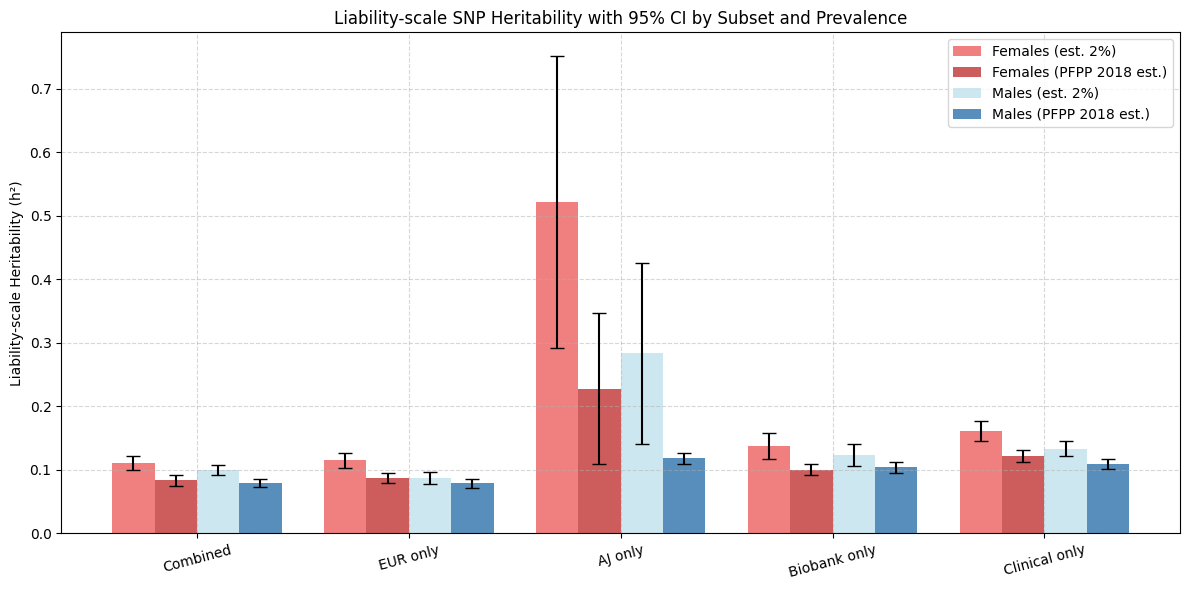

In [106]:
import matplotlib.pyplot as plt
import numpy as np

# Subsets
subsets = ['Combined', 'EUR only', 'AJ only', 'Biobank only', 'Clinical only']
x = np.arange(len(subsets))
width = 0.2

# h² values
f_h2_2 = np.array([0.1107, 0.1148, 0.5216, 0.1379, 0.1609])
f_se_2 = np.array([0.0110, 0.0112, 0.2296, 0.0207, 0.0156])

f_h2_age = np.array([0.0836, 0.0877, 0.2278, 0.1004, 0.1215])
f_se_age = np.array([0.0091, 0.0077, 0.1186, 0.0087, 0.0093])

m_h2_2 = np.array([0.0994, 0.0867, 0.2837, 0.1232, 0.1333])
m_se_2 = np.array([0.0082, 0.0094, 0.1425, 0.0172, 0.0122])

m_h2_age = np.array([0.0793, 0.0787, 0.1186, 0.1042, 0.1094])
m_se_age = np.array([0.0064, 0.0069, 0.0086, 0.0084, 0.0082])

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - 1.5*width, f_h2_2, width, yerr=f_se_2, capsize=5, label='Females (est. 2%)', color='lightcoral')
ax.bar(x - 0.5*width, f_h2_age, width, yerr=f_se_age, capsize=5, label='Females (PFPP 2018 est.)', color='indianred')

ax.bar(x + 0.5*width, m_h2_2, width, yerr=m_se_2, capsize=5, label='Males (est. 2%)', color='lightblue', alpha=0.6)
ax.bar(x + 1.5*width, m_h2_age, width, yerr=m_se_age, capsize=5, label='Males (PFPP 2018 est.)', color='steelblue', alpha=0.9)

# Labels and formatting
ax.set_ylabel('Liability-scale Heritability (h²)')
ax.set_title('Liability-scale SNP Heritability with 95% CI by Subset and Prevalence')
ax.set_xticks(x)
ax.set_xticklabels(subsets, rotation=15)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
